In [1]:
import matplotlib.pyplot as plt
import numpy as np
from configurations import apply_general_styles, set_font_sizes, create_fig
from tracklab import ExperimentReader

apply_general_styles()
set_font_sizes(conf='tight')

In [2]:
experiment_name = "tmp_theory"
reader = ExperimentReader(experiment_name,base_dir="../data")

list_runs = reader.list_runs()
run_id = list_runs[-1]  # Get the most recent run
print(f"Loading run with id: {run_id}")

list_artifacts = reader.list_artifacts(run_id)
df = reader.load_metrics(run_id)

# Get unique "metrics" from df
# df.head()
unique_metrics = df["metric"].unique().tolist()
print(unique_metrics)

Loading run with id: run_008
['top1_accuracy', 'top3_accuracy', 'loss', 'm', 'gamma', 'eta', 'q', 'sigma1', 'loss_eff', 'P_prev', 'P_ind', 'delta_L', 'SNR_layer1', 'SNR_layer2', 'pi', 'gain_term']


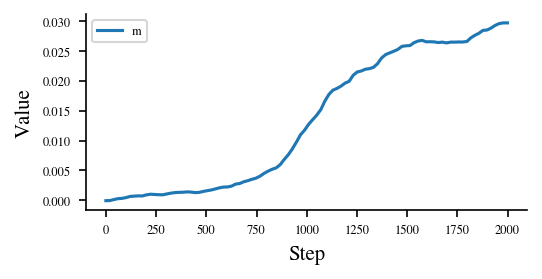

In [4]:

metrics = ["m"]

fig , axes = create_fig()
ax = axes
for metric in metrics:
    x = df[df["metric"] == metric]["step"]
    y = df[df["metric"] == metric]["value"]
    ax.plot(x, y, label=metric)
ax.set_xlabel("Step")   
ax.set_ylabel("Value")
ax.legend()
# ax.set_xscale("log")

In [53]:
np.sqrt(2000)*0.025

np.float64(1.118033988749895)

In [42]:
list_artifacts
attn1_files = list_artifacts[list_artifacts['file'].str.contains('attn1')]
print(attn1_files)

     step                 file
0     0.0     attn1_step_0.npy
2   499.0   attn1_step_499.npy
4   999.0   attn1_step_999.npy
6  1499.0  attn1_step_1499.npy
8  1999.0  attn1_step_1999.npy


In [36]:
batch_file = list_artifacts['file'].iloc[-1]
batch = reader.load_artifact(run_id, batch_file)
print(batch.keys())
for key in batch.keys():
    print(f"{key}: {batch[key].shape}")

dict_keys(['sequence', 'trigger_set', 'output_set', 'counts', 'is_trigg', 'mask'])
sequence: torch.Size([10, 129])
trigger_set: torch.Size([10, 10])
output_set: torch.Size([10, 10])
counts: torch.Size([10, 128])
is_trigg: torch.Size([10, 128])
mask: torch.Size([10, 128, 128])


In [37]:
sequence = batch['sequence']
sequence.shape

torch.Size([10, 129])

In [38]:
def _make_text(list,nplaces=2):
    str_list = [f"{x:{nplaces}d}" for x in list]
    return " |".join(str_list)

# Define a function to plot empty squares for mask=1 on an existing axis
def plot_mask_squares(ax, mask,lw=0.5,color='red',alpha=1.0):
    """
    Plots empty squares on the given axis where mask=1.

    Parameters:
    ax : matplotlib.axes.Axes
        The axis on which to plot the squares.
    mask : numpy.ndarray
        A 2D array where squares are drawn for elements equal to 1.
    """
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j] == 1:
                rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor=color, linewidth=lw, alpha=alpha)
                ax.add_patch(rect)
    ax.set_xlim(-0.5, mask.shape[1] - 0.5)
    ax.set_ylim(-0.5, mask.shape[0] - 0.5)
    ax.invert_yaxis()
    ax.set_aspect('equal')



(128, 128)


Trigger Set: 	 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Output Set: 	 [24, 21, 10, 22, 1, 30, 17, 12, 21, 31]
InPos: 		  0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |10 |11 |12 |13 |14 |15 |16 |17 |18 |19 |20 |21 |22 |23 |24 |25 |26 |27 |28 |29 |30 |31 |32 |33 |34 |35 |36 |37 |38 |39 |40 |41 |42 |43 |44 |45 |46 |47 |48 |49 |50 |51 |52 |53 |54 |55 |56 |57 |58 |59 |60 |61 |62 |63 |64 |65 |66 |67 |68 |69 |70 |71 |72 |73 |74 |75 |76 |77 |78 |79 |80 |81 |82 |83 |84 |85 |86 |87 |88 |89 |90 |91 |92 |93 |94 |95 |96 |97 |98 |99 |100 |101 |102 |103 |104 |105 |106 |107 |108 |109 |110 |111 |112 |113 |114 |115 |116 |117 |118 |119 |120 |121 |122 |123 |124 |125 |126 |127
Input: 		  5 |30 |16 |15 | 4 | 1 |21 |12 | 8 |21 |16 |30 | 8 |21 | 6 |17 |21 |24 |22 |12 |26 |10 | 8 |21 | 8 |21 | 5 |30 | 9 |31 | 8 |21 |19 | 0 |24 | 9 |31 |20 | 6 |17 |24 |31 | 7 |12 |22 | 2 |10 |17 |26 |30 |28 |13 |13 |14 |19 |16 |23 |19 |17 |10 |18 |28 |20 | 9 |31 | 8 |21 |17 |31 |11 | 8 |21 | 7 |12 |12 | 7 |12 |14 |28 |27 |30 |27 |16 | 1 |21 |1

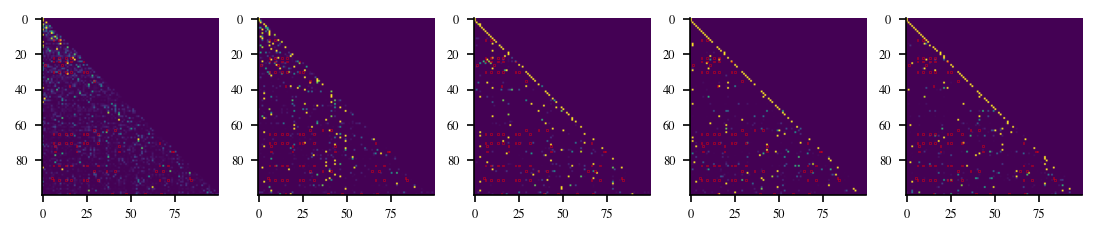

In [45]:
i_batch = 1

l = 100
ncols = len(attn1_files)

trigger_set = batch['trigger_set'][i_batch].tolist()
output_set = batch['output_set'][i_batch].tolist()
input = batch['sequence'][i_batch,:-1].tolist()
is_trigg = batch['is_trigg'][i_batch].tolist()
counts = batch['counts'][i_batch].tolist()

mask = np.zeros((len(input), len(input)))
print(mask.shape)
for i in range(mask.shape[0]):
    if is_trigg[i] == 1 and counts[i] > 1:
        trig = input[i]
        out = output_set[trigger_set.index(trig)]
        for j in range(i):
            if input[j] == out:
                mask[i,j] = 1
mask = mask[:l,:l]


fig , axes = create_fig(ncols=ncols, size='double',h=0.2)

for i , file in enumerate(attn1_files['file']):
    attn = reader.load_artifact(run_id, file)[i_batch][:l,:l]
    ax = axes[i]
    ax.imshow(attn, aspect='auto', cmap='viridis',vmax=0.5)
    plot_mask_squares(ax, mask,lw=0.4,alpha=0.5,color='r')

    
    # ax.set_title(file)
    # fig.colorbar(im, ax=ax)

print(f"Trigger Set: \t {trigger_set}")
print(f"Output Set: \t {output_set}")
print(f"InPos: \t\t {_make_text(np.arange(len(input)))}")
print(f"Input: \t\t {_make_text(input)}")
print(f"Is Trigger: \t {_make_text(is_trigg)}")
print(f"Counts: \t {_make_text(counts)}")

In [46]:
dic1 = {'a': 1, 'b': 2}
dic2 = {'c':3, 'd':4}

dic = {**dic1, **dic2}
print(dic)

{'a': 1, 'b': 2, 'c': 3, 'd': 4}
